## **<font color="red">Sklearn Ridge Regression</font>**

Dataset Shape:  (442, 10)
R2_Score: 0.4693
Weights: [  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
Bias: 150.89053425602808


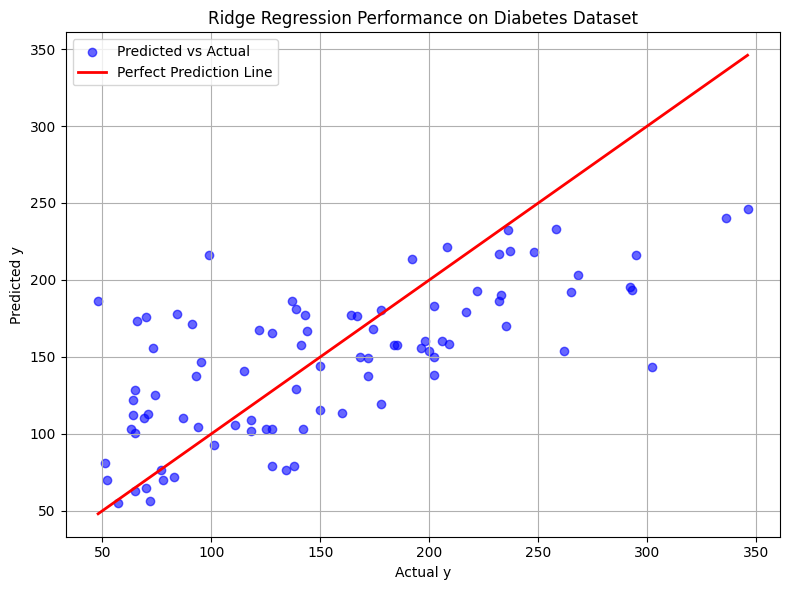

In [7]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
import numpy as np
import matplotlib.pyplot as plt

# ============ Load and Split Data ============
X, y = load_diabetes(return_X_y=True)
print("Dataset Shape: ", X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# ============ Model ============
rg = Ridge(alpha=0.1, solver="cholesky")
rg.fit(X_train, y_train)

y_pred = rg.predict(X_test)
r2s = r2_score(y_test, y_pred)
print(f"R2_Score: {r2s:.4f}")
print(f"Weights: {rg.coef_}")
print(f"Bias: {rg.intercept_}")

# ============ Plots ============
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.6, label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", lw=2, label="Perfect Prediction Line")
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Ridge Regression Performance on Diabetes Dataset")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## **<font color="red">Custome Ridge Regression for N Features</font>**

Dataset Shape:  (442, 10)
Alpha: 0.1
Bias: 150.89053425602808
Weights shape: [  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
R2 Score (custom ridge): 0.4693


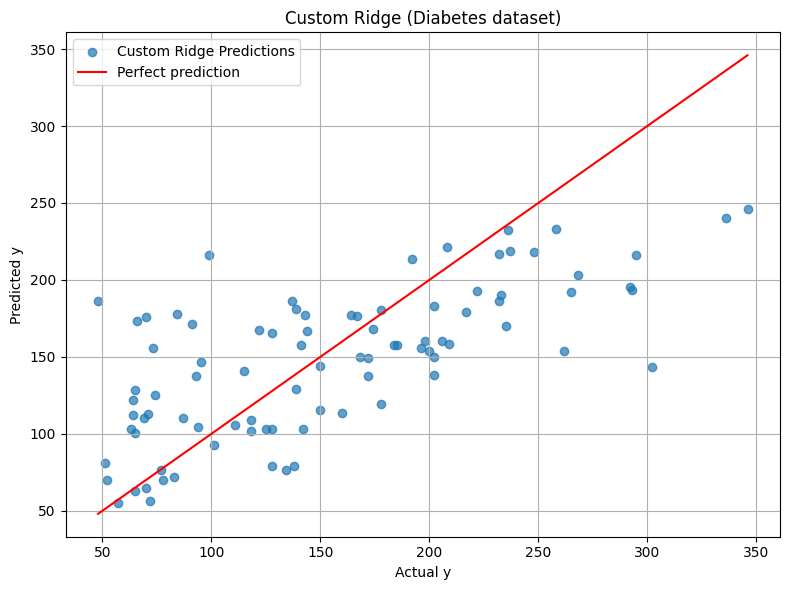

In [16]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# ============ Load and Split Data ============
X, y = load_diabetes(return_X_y=True)
print("Dataset Shape: ", X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# =========== Custom Ridge Class ==============
class CustomeRidge:
    def __init__(self, alpha=0.1):
        self.__alpha = float(alpha)
        self.__weights = None  # shape (n_features,)
        self.__bias = None     # scalar
        
    def fit(self, X_train, y_train):
        # Ensure numpy arrays and correct shapes
        X_train = np.asarray(X_train, dtype=float)
        y_train = np.asarray(y_train, dtype=float)
        n_samples, n_features = X_train.shape
        
        # Build design matrix with intercept column
        Xb = np.hstack([np.ones((n_samples, 1)), X_train])  # shape (n_samples, n_features+1)
        
        # Regularization matrix: do not regularize the intercept (first element = 0)
        I = np.eye(n_features + 1)
        I[0, 0] = 0.0
        
        # Closed-form ridge solution: (Xb^T Xb + alpha * I)^-1 Xb^T y
        A = Xb.T.dot(Xb) + self.__alpha * I
        # Use np.linalg.solve for better numerical stability than inv
        result = np.linalg.solve(A, Xb.T.dot(y_train))
        
        self.__bias = float(result[0])
        self.__weights = result[1:].reshape(-1)  # flatten to 1D
        
        print(f"Alpha: {self.__alpha}")
        print(f"Bias: {self.__bias}")
        print(f"Weights shape: {self.__weights}")
        
    def predict(self, X_test):
        X_test = np.asarray(X_test, dtype=float)
        # Ensure proper shape for single sample
        if X_test.ndim == 1:
            X_test = X_test.reshape(1, -1)
        preds = X_test.dot(self.__weights) + self.__bias
        # If multiple samples, return 1-D array; if single sample, return 1-D as well
        return np.asarray(preds).reshape(-1)

# =========== Use the Custom Ridge ============
custom_reg = CustomeRidge(alpha=0.1)
custom_reg.fit(X_train, y_train)

y_pred = custom_reg.predict(X_test)
score = r2_score(y_test, y_pred)
print(f"R2 Score (custom ridge): {score:.4f}")

# =========== Plot: Predicted vs Actual ============
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, label="Custom Ridge Predictions")
minv = min(y_test.min(), y_pred.min())
maxv = max(y_test.max(), y_pred.max())
plt.plot([minv, maxv], [minv, maxv], color="red", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Custom Ridge (Diabetes dataset)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# ============ Load and Split Data ============
X, y = load_diabetes(return_X_y=True)
print("Dataset Shape: ", X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# =========== Custom Ridge Calss ==============
class CustomeRidge:
    def __init__(self, alpha=0.1):
        self.__alpha = alpha
        self.__weights = None
        self.__bias = None
        
    def fit(self, X_train, y_train):
        X_train = np.insert(X_train, 0, 1, axis=1)  # insert a column with value 1 at 0th place
        I  = np.identity(X_train.shape[1])
        result = np.linalg.inv(np.dot(X_train.T, X_train) + self.__alpha * I).dot(X_train.T).dot(y_train)
        self.__bias = result[0]
        self.__weights = result[1:]
        print(f"Weights: {self.__weights}")
        print(f"Bias: {self.__bias}")
        
    def predict(self, X_test):
        return np.dot(X_test, self.__weights) + self.__bias


custom_reg = CustomeRidge()
custom_reg.fit(X_train, y_train)
y_pred = custom_reg.predict(X_test)
print("R2 Score: ", r2_score(y_test, y_pred))


Dataset Shape:  (442, 10)
Weights: [  44.04252774 -241.72019592  452.99153345  332.06044266  -76.32617866
  -68.54884462 -165.01664054  149.93980143  431.59483654   58.54419942]
Bias: 150.84762720023164
R2 Score:  0.46921361559931896
